# TDCSophiread Clustering and Visualization

Complete workflow for processing TPX3 data through clustering with cluster ID propagation and interactive visualization.

**What this notebook does:**
1. Process TPX3 file to hits with zero-copy numpy access
2. Apply ABS clustering to extract neutron events with cluster ID tracking
3. Analyze cluster size distributions and spatial patterns
4. Count neutrons in ROI (100<x<300, 100<y<250)
5. Create 2D/3D interactive Plotly visualizations with consistent cluster coloring
6. Analyze TOF spectra for hits and neutrons

**Key features:**
- Cluster IDs propagated from C++ to Python via structured numpy arrays
- Discrete color mapping ensures same cluster ID = same color
- Interactive HTML outputs with customizable time slicing
- Sub-pixel neutron position resolution

**Data:** `OB_1800_1100_500V_1mins000000.tpx3` (NECL-plate efficiency measurement)

> NOTE: Requires rebuilt tdcsophiread with cluster_id copy-back support. Run on M2 Max MacBook Pro with 32GB RAM.

## 1. Setup and Import

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import tdcsophiread as tdc

print(f"TDCSophiread version: {tdc.__version__}")
print(f"Numpy version: {np.__version__}")

# Setup plotting
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

TDCSophiread version: 3.1.3
Numpy version: 2.3.3


/Users/uff/ORNL Dropbox/Fumiaki Funama/Research/Experiments/Cycle513/mcpevent2hist/sophiread/.pixi/envs/default/lib/python3.13/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
# def visualize_clusters(x, y, t, cluster_arr, Pixel2mm=1, save_dir='.', prefix='cluster_viz'):
#     x = np.asarray(x) * Pixel2mm
#     y = np.asarray(y) * Pixel2mm
#     t = np.asarray(t)
#     cluster = np.asarray(cluster_arr)
#     df = pd.DataFrame({'x': x, 'y': y, 't': t, 'cluster': cluster})

#     # 2D scatter colored by cluster id (categorical if few labels)
#     fig2 = px.scatter(df, x='x', y='y', color='cluster', opacity=0.6,
#                      title=f'{prefix}_2D', width=800, height=800)
#     fig2.show()  # Display inline instead of saving

#     # 3D scatter (x,y,time)
#     try:
#         t_plot = df['t'] / 1000.0  # ns -> us if applicable
#     except Exception:
#         t_plot = df['t']
#     df['t_plot'] = t_plot
#     fig3 = px.scatter_3d(df, x='x', y='y', z='t_plot', color='cluster', opacity=0.6,
#                      title=f'{prefix}_3D', width=900, height=700,
#                      labels={'x': 'x', 'y': 'y', 't_plot': 't [μs]'})
#     fig3.show()  # Display inline instead of saving

#     return None, None  # or remove return statement

In [3]:
def visualize_clusters(x, y, t, cluster_arr, Pixel2mm=1, save_dir='.', prefix='cluster_viz'):
    # os.makedirs(save_dir, exist_ok=True)
    
    x = np.asarray(x) * Pixel2mm
    y = np.asarray(y) * Pixel2mm
    t = np.asarray(t)
    cluster = np.asarray(cluster_arr)
    
    # Get unique cluster IDs and create color mapping
    unique_ids = np.unique(cluster)
    n_clusters = len(unique_ids)
    
    # Convert to categorical for discrete colors
    df = pd.DataFrame({
        'x': x, 
        'y': y, 
        't': t, 
        'cluster': cluster.astype(str)  # Convert to string for discrete treatment
    })
    
    # Use a palette with enough colors (cycle if needed)
    colors = px.colors.qualitative.Dark24  # 24 colors
    color_map = {str(cid): colors[i % len(colors)] for i, cid in enumerate(unique_ids)}

    # 2D scatter with discrete colors
    fig2 = px.scatter(df, x='x', y='y', color='cluster', 
                     color_discrete_map=color_map,
                     opacity=0.6,
                     title=f'{prefix}_2D (n_clusters={n_clusters})', 
                     width=800, height=800)
    out2 = os.path.join(save_dir, f'{prefix}_2D.html')
    # fig2.write_html(out2)
    fig2.show()

    # 3D scatter
    try:
        t_plot = df['t'] / 1000.0  # ns -> us
    except Exception:
        t_plot = df['t']
    df['t_plot'] = t_plot
    
    fig3 = px.scatter_3d(df, x='x', y='y', z='t_plot', color='cluster',
                     color_discrete_map=color_map,
                     opacity=0.6,
                     title=f'{prefix}_3D (n_clusters={n_clusters})', 
                     width=900, height=700,
                     labels={'x': 'x', 'y': 'y', 't_plot': 't [μs]'})
    out3 = os.path.join(save_dir, f'{prefix}_3D.html')
    # fig3.write_html(out3)
    fig3.show()
    
    return out2, out3

## 2. Data File Setup

In [4]:
# Ni powder file path
data_path = "/Users/uff/ORNL Dropbox/Fumiaki Funama/Research/Experiments/Cycle513/Data/NECL-plate/Efficiency/"
ni_file = "OB_1800_1100_500V_1mins000000.tpx3"
ni_full_path = os.path.join(data_path, ni_file)

# Verify file exists
if os.path.exists(ni_full_path):
    size_mb = os.path.getsize(ni_full_path) / (1024 * 1024)
    print(f"✅ Ni powder file found: {ni_file}")
    print(f"   Size: {size_mb:.1f} MB")
else:
    print(f"❌ File not found: {ni_full_path}")
    print("Please ensure the data file is in the correct location")

✅ Ni powder file found: OB_1800_1100_500V_1mins000000.tpx3
   Size: 17.3 MB


## 3. Raw Data → Hits Processing

In [5]:
print("=== Processing TPX3 file to hits ===")

start_time = time.time()

# Process the file using TDCSophiread (high-level convenience function)
# NEW: Returns TDCHitView for zero-copy numpy access
hit_view = tdc.process_tpx3(ni_full_path, parallel=True)

# Convert to numpy array (zero-copy)
hits = np.array(hit_view, copy=False)

processing_time = time.time() - start_time

print(f"✅ Processing completed in {processing_time:.2f} seconds")
print(f"✅ Total hits extracted: {len(hits):,}")
print(f"✅ Processing rate: {len(hits) / processing_time / 1e6:.1f} M hits/second")

# Display hit data structure
print("\nHit data structure:")
for field in hits.dtype.names:
    array = hits[field]
    print(f"  {field}: {array.dtype}, shape {array.shape}")
    print(f"    range: {array.min()} - {array.max()}")

=== Processing TPX3 file to hits ===
✅ Processing completed in 0.06 seconds
✅ Total hits extracted: 2,168,426
✅ Processing rate: 38.0 M hits/second

Hit data structure:
  tof: uint32, shape (2168426,)
    range: 0 - 1999789
  x: uint16, shape (2168426,)
    range: 0 - 513
  y: uint16, shape (2168426,)
    range: 0 - 513
  timestamp: uint32, shape (2168426,)
    range: 7386 - 1074057033
  tot: uint16, shape (2168426,)
    range: 0 - 448
  chip_id: uint8, shape (2168426,)
    range: 0 - 3
  cluster_id: int32, shape (2168426,)
    range: -1 - -1


In [6]:
tot_ns = hits["tot"][:]
        # ftoa_ns = h5f["ftoa_ns"][:]
spidertime_ns = hits["timestamp"][:]
cluster_id = hits["cluster_id"][:]

print("Unique hit cluster_id (sample):", np.unique(hits["cluster_id"])[:10])
# show first 20 cluster_id values to inspect
print(hits["cluster_id"][:200])

Unique hit cluster_id (sample): [-1]
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]


In [7]:
print("=== Setting up clustering configuration ===")

# Create neutron processing configuration with VENUS defaults
config = tdc.NeutronProcessingConfig.venus_defaults()
config.extraction.min_tot_threshold = 0
config.temporal.enable_deduplication = False

## No super resolution
config.extraction.super_resolution_factor=1

print("VENUS default neutron processing configuration:")
print(f"  Clustering algorithm: {config.clustering.algorithm}")
print(f"  Extraction algorithm: {config.extraction.algorithm}")

print("\nABS clustering parameters:")
print(f"  Spatial radius: {config.clustering.abs.radius} pixels")
print(f"  Min cluster size: {config.clustering.abs.min_cluster_size} hits")
print(f"  Time range: {config.clustering.abs.neutron_correlation_window} ns")

print("\nCentroid extraction parameters:")
print(f"  Super resolution: {config.extraction.super_resolution_factor}x")
print(f"  TOT weighted: {config.extraction.weighted_by_tot}")
print(f"  Min TOT threshold: {config.extraction.min_tot_threshold}")

print("\nTemporal processing parameters:")
print(f"  Number of workers: {config.temporal.num_workers}")
print(f"  Min batch size: {config.temporal.min_batch_size}")
print(f"  Max batch size: {config.temporal.max_batch_size}")

=== Setting up clustering configuration ===
VENUS default neutron processing configuration:
  Clustering algorithm: abs
  Extraction algorithm: simple_centroid

ABS clustering parameters:
  Spatial radius: 5.0 pixels
  Min cluster size: 1 hits
  Time range: 75.0 ns

Centroid extraction parameters:
  Super resolution: 1.0x
  TOT weighted: True
  Min TOT threshold: 0

Temporal processing parameters:
  Number of workers: 0
  Min batch size: 1000
  Max batch size: 100000


## 5. Hits → Neutrons Clustering

In [8]:
print("=== Clustering hits to neutrons ===")
print(f"Input: {len(hits):,} hits")

start_time = time.time()

# Process hits to neutrons using the new zero-copy interface
# This function accepts both numpy arrays and TDCHitView
neutron_view = tdc.process_hits_to_neutrons(hits, config)

clustering_time = time.time() - start_time

print(f"✅ Clustering completed in {clustering_time:.2f} seconds")

=== Clustering hits to neutrons ===
Input: 2,168,426 hits
✅ Clustering completed in 0.03 seconds


In [9]:
print("Exposing neutron data as numpy array for zero-copy access")
start_time = time.time()
# Convert to numpy array (zero-copy)
neutrons = np.array(neutron_view, copy=False)
processing_time = time.time() - start_time
print(f"✅ Neutron data exposed in {processing_time:.2f} seconds")
print(f"✅ Output neutrons: {len(neutrons):,}")
print(f"✅ Clustering rate: {len(hits) / clustering_time:.0f} hits/second")


Exposing neutron data as numpy array for zero-copy access
✅ Neutron data exposed in 0.00 seconds
✅ Output neutrons: 131,749
✅ Clustering rate: 62736081 hits/second


In [10]:
# Calculate clustering efficiency
efficiency = len(neutrons) / len(hits)
print(f"✅ Neutron extraction efficiency: {efficiency:.6f} ({efficiency * 100:.4f}%)")

# Display neutron data structure
print("\nNeutron data structure:")
for field in neutrons.dtype.names:
    array = neutrons[field]
    print(f"  {field}: {array.dtype}, shape {array.shape}")
    if field in ["x", "y"]:
        print(f"    range: {array.min():.2f} - {array.max():.2f} (sub-pixel)")
    else:
        print(f"    range: {array.min()} - {array.max()}")

✅ Neutron extraction efficiency: 0.060758 (6.0758%)

Neutron data structure:
  x: float64, shape (131749,)
    range: 0.00 - 513.00 (sub-pixel)
  y: float64, shape (131749,)
    range: 0.00 - 513.00 (sub-pixel)
  tof: uint32, shape (131749,)
    range: 0 - 1999788
  tot: uint16, shape (131749,)
    range: 1 - 33937
  n_hits: uint16, shape (131749,)
    range: 1 - 4461
  chip_id: uint8, shape (131749,)
    range: 0 - 3
  reserved: uint8, shape (131749,)
    range: 0 - 0


## 6. Clustering Results Analysis

In [11]:
print("=== Clustering Results Analysis ===")

# Get neutron fields directly (now it's a structured numpy array)
n_hits_field = neutrons["n_hits"]
x_field = neutrons["x"]
y_field = neutrons["y"]

tot_ns = hits["tot"][:]
        # ftoa_ns = h5f["ftoa_ns"][:]
spidertime_ns = hits["timestamp"][:]
cluster_id = hits["cluster_id"][:]

# Cluster size distribution
cluster_sizes, counts = np.unique(n_hits_field, return_counts=True)
print(f"\nCluster size distribution (showing first 10):")
for size, count in zip(cluster_sizes[:10], counts[:10]):
    percentage = 100 * count / len(neutrons)
    print(f"  {size} hits: {count:,} neutrons ({percentage:.2f}%)")

if len(cluster_sizes) > 10:
    print(f"  ... (total {len(cluster_sizes)} different cluster sizes)")

# Single vs multi-hit clusters
single_hit = counts[cluster_sizes == 1][0] if 1 in cluster_sizes else 0
multi_hit = len(neutrons) - single_hit
print(f"\nCluster composition:")
print(
    f"  Single-hit neutrons: {single_hit:,} ({100 * single_hit / len(neutrons):.1f}%)"
)
print(f"  Multi-hit neutrons: {multi_hit:,} ({100 * multi_hit / len(neutrons):.1f}%)")
print(f"  Mean cluster size: {n_hits_field.mean():.1f} hits")

# Sub-pixel precision check
x_fractional = x_field - np.floor(x_field)
y_fractional = y_field - np.floor(y_field)
non_integer_x = np.sum(x_fractional > 0.001)
non_integer_y = np.sum(y_fractional > 0.001)

print(f"\nSub-pixel precision:")
print(
    f"  Non-integer X coordinates: {non_integer_x:,} ({100 * non_integer_x / len(neutrons):.1f}%)"
)
print(
    f"  Non-integer Y coordinates: {non_integer_y:,} ({100 * non_integer_y / len(neutrons):.1f}%)"
)
print(f"  X fractional range: {x_fractional.min():.3f} - {x_fractional.max():.3f}")
print(f"  Y fractional range: {y_fractional.min():.3f} - {y_fractional.max():.3f}")

=== Clustering Results Analysis ===

Cluster size distribution (showing first 10):
  1 hits: 12,904 neutrons (9.79%)
  2 hits: 8,734 neutrons (6.63%)
  3 hits: 5,574 neutrons (4.23%)
  4 hits: 7,362 neutrons (5.59%)
  5 hits: 4,158 neutrons (3.16%)
  6 hits: 4,796 neutrons (3.64%)
  7 hits: 4,636 neutrons (3.52%)
  8 hits: 4,275 neutrons (3.24%)
  9 hits: 4,421 neutrons (3.36%)
  10 hits: 3,935 neutrons (2.99%)
  ... (total 319 different cluster sizes)

Cluster composition:
  Single-hit neutrons: 12,904 (9.8%)
  Multi-hit neutrons: 118,845 (90.2%)
  Mean cluster size: 16.5 hits

Sub-pixel precision:
  Non-integer X coordinates: 112,979 (85.8%)
  Non-integer Y coordinates: 114,213 (86.7%)
  X fractional range: 0.000 - 1.000
  Y fractional range: 0.000 - 1.000


## 7. Spatial Distribution Visualization

In [12]:
det_venus_config = tdc.DetectorConfig.venus_defaults()

det_venus_config.get_chip_size_x(), det_venus_config.get_chip_size_y()

(256, 256)

=== Creating spatial distribution visualizations ===



Creating hits 2D histogram...
Creating neutrons 2D histogram...


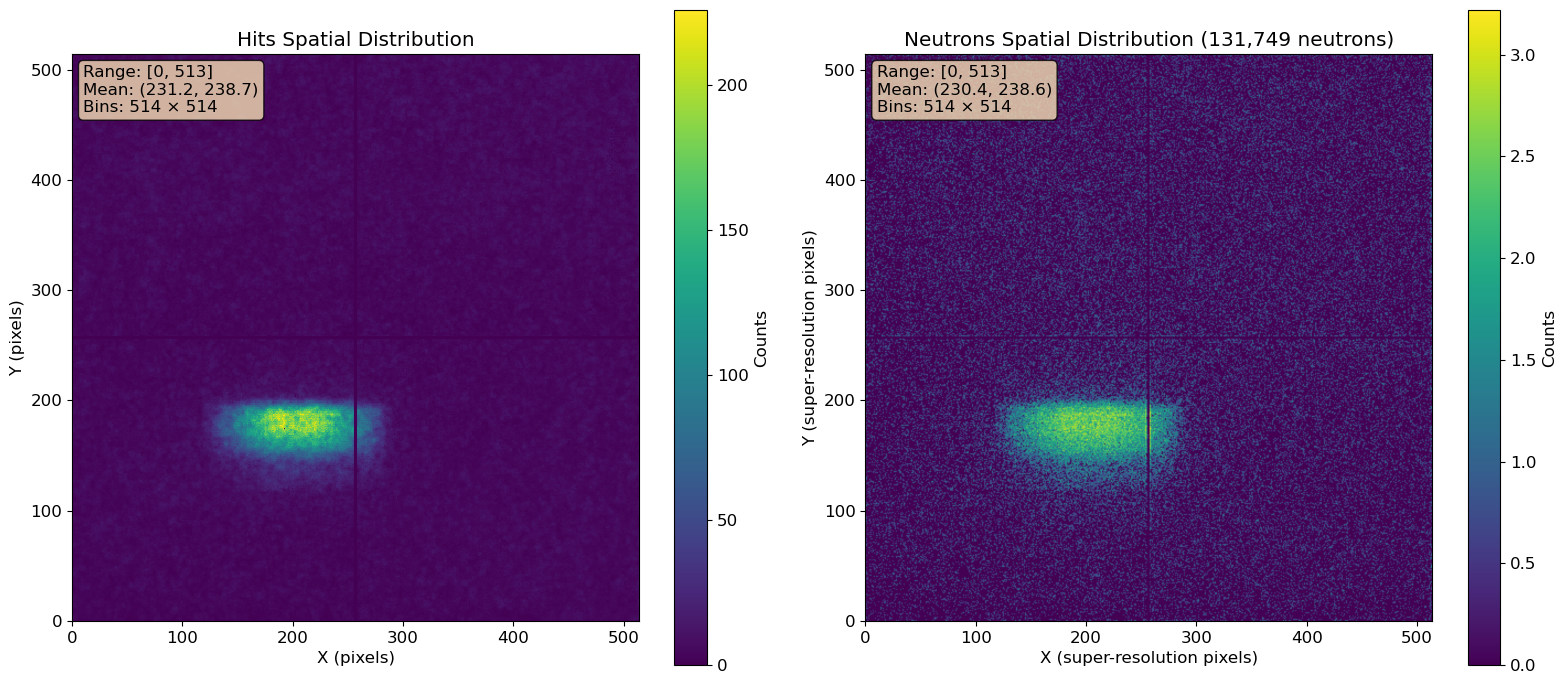


=== Spatial Distribution Analysis ===
Detector configuration: 514×514 pixels
Super-resolution factor: 1.0x

Hits (native pixels):
  X range: 0 - 513
  Y range: 0 - 513
  Total hits: 2,168,426

Neutrons (super-resolution pixels):
  X range: 0.0 - 513.0
  Y range: 0.0 - 513.0
  Total neutrons: 131,749
  Data reduction: 16.5:1


In [13]:
print("=== Creating spatial distribution visualizations ===")

# VENUS detector has 514x514 pixels (256*2 + 2 pixel gap)
DETECTOR_PIXELS = det_venus_config.get_chip_size_x() * 2 + 2

# use super-resolution factor from config
NEUTRON_SUPER_RES = config.extraction.super_resolution_factor

# Create figure with two subplots for better comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Hits distribution (native pixels)
print("\nCreating hits 2D histogram...")
# Sample hits for performance
# sample_size = 500_000
# indices = np.random.choice(len(hits), sample_size, replace=False)
hits_x_sample = hits["x"]
hits_y_sample = hits["y"]

# Use 514 bins for native pixel data (one bin per detector pixel)
hist_hits, x_edges, y_edges = np.histogram2d(
    hits_x_sample,
    hits_y_sample,
    bins=DETECTOR_PIXELS,
    range=[[0, DETECTOR_PIXELS], [0, DETECTOR_PIXELS]],
)

im1 = ax1.imshow(
    hist_hits,
    origin="lower",
    aspect="equal",
    extent=[0, DETECTOR_PIXELS, 0, DETECTOR_PIXELS],
    cmap="viridis",
    interpolation="none",
)
ax1.set_xlabel("X (pixels)")
ax1.set_ylabel("Y (pixels)")
ax1.set_title(f"Hits Spatial Distribution")
plt.colorbar(im1, ax=ax1, label="Counts")

# Add statistics
stats_text = f"Range: [{hits_x_sample.min()}, {hits_x_sample.max()}]\n"
stats_text += f"Mean: ({hits_x_sample.mean():.1f}, {hits_y_sample.mean():.1f})\n"
stats_text += f"Bins: {DETECTOR_PIXELS} × {DETECTOR_PIXELS}"
ax1.text(
    0.02,
    0.98,
    stats_text,
    transform=ax1.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Plot 2: Neutrons distribution (super-resolution pixels)
print("Creating neutrons 2D histogram...")
# Use detector and clustering configuration to determine bins
NEUTRON_BINS = int(DETECTOR_PIXELS * NEUTRON_SUPER_RES)
neutrons_x = neutrons["x"]
neutrons_y = neutrons["y"]
x_min, x_max = neutrons_x.min(), neutrons_x.max()
y_min, y_max = neutrons_y.min(), neutrons_y.max()

hist_neutrons, x_edges_n, y_edges_n = np.histogram2d(
    neutrons_x,
    neutrons_y,
    bins=NEUTRON_BINS,
    range=[[0, NEUTRON_BINS], [0, NEUTRON_BINS]],
    # range=[[x_min, x_max], [y_min, y_max]],
)

im2 = ax2.imshow(
    np.log1p(hist_neutrons),
    origin="lower",
    aspect="equal",
    extent=[0, NEUTRON_BINS, 0, NEUTRON_BINS],
    # extent=[x_min, x_max, y_min, y_max],
    cmap="viridis",
    interpolation="gaussian",  # this is critical when we have too many 1 hit neutrons
)
ax2.set_xlabel("X (super-resolution pixels)")
ax2.set_ylabel("Y (super-resolution pixels)")
ax2.set_title(f"Neutrons Spatial Distribution ({len(neutrons):,} neutrons)")
plt.colorbar(im2, ax=ax2, label="Counts")

# Add statistics
stats_text = f"Range: [{neutrons_x.min():.0f}, {neutrons_x.max():.0f}]\n"
stats_text += f"Mean: ({neutrons_x.mean():.1f}, {neutrons_y.mean():.1f})\n"
stats_text += f"Bins: {NEUTRON_BINS} × {NEUTRON_BINS}"
ax2.text(
    0.02,
    0.98,
    stats_text,
    transform=ax2.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n=== Spatial Distribution Analysis ===")
print(f"Detector configuration: {DETECTOR_PIXELS}×{DETECTOR_PIXELS} pixels")
print(f"Super-resolution factor: {NEUTRON_SUPER_RES}x")

print("\nHits (native pixels):")
print(f"  X range: {hits['x'].min()} - {hits['x'].max()}")
print(f"  Y range: {hits['y'].min()} - {hits['y'].max()}")
print(f"  Total hits: {len(hits):,}")

print("\nNeutrons (super-resolution pixels):")
print(f"  X range: {neutrons_x.min():.1f} - {neutrons_x.max():.1f}")
print(f"  Y range: {neutrons_y.min():.1f} - {neutrons_y.max():.1f}")
print(f"  Total neutrons: {len(neutrons):,}")
print(f"  Data reduction: {len(hits) / len(neutrons):.1f}:1")

In [14]:
# Count neutrons in ROI 100 < x < 300 and 100 < y < 250
x = neutrons['x']
y = neutrons['y']
mask = (x > 100) & (x < 300) & (y > 100) & (y < 250)
count = np.count_nonzero(mask)
print(f"Neutrons in ROI (100<x<300, 100<y<250): {count:,}")
# Also print fraction of total neutrons
fraction = count / len(neutrons) if len(neutrons) > 0 else 0
print(f"Fraction of total neutrons: {fraction:.4%}")

Neutrons in ROI (100<x<300, 100<y<250): 53,534
Fraction of total neutrons: 40.6333%


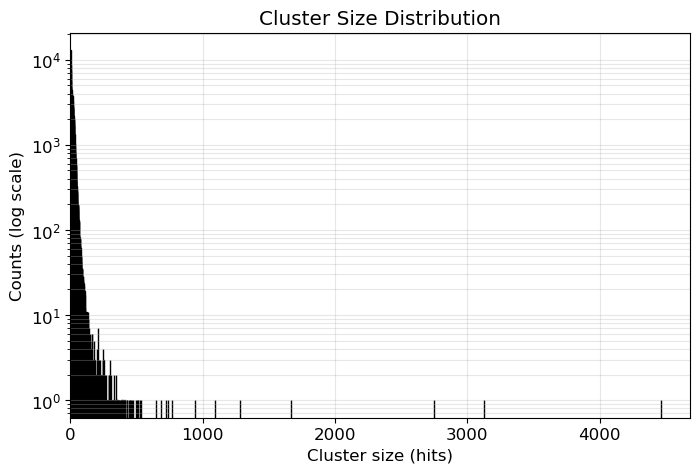

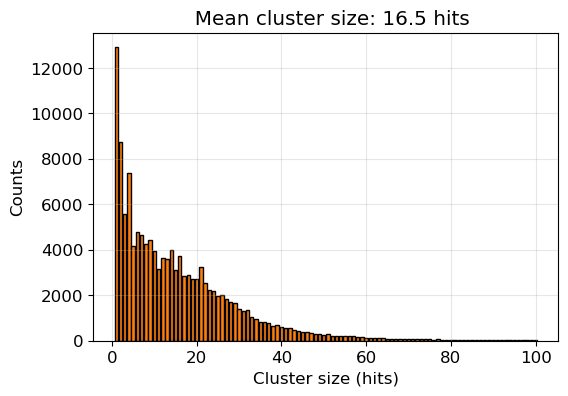

In [15]:
# Cluster size distribution figure
# Uses `n_hits_field` computed in the clustering analysis cell
sizes, counts = np.unique(n_hits_field, return_counts=True)
import matplotlib.pyplot as plt
# Full distribution (log y)
plt.figure(figsize=(8,5))
plt.bar(sizes, counts, color='C0', edgecolor='k')
plt.yscale('log')
plt.xlabel('Cluster size (hits)')
plt.ylabel('Counts (log scale)')
plt.title('Cluster Size Distribution')
plt.grid(True, alpha=0.3, which='both')
plt.xlim(left=0)
plt.show()

# Zoomed view for small cluster sizes (1-10)
small_mask = sizes <= 100
if small_mask.any():
    plt.figure(figsize=(6,4))
    plt.bar(sizes[small_mask], counts[small_mask], color='C1', edgecolor='k')
    plt.xlabel('Cluster size (hits)')
    plt.ylabel('Counts')
    plt.title(f"  Mean cluster size: {n_hits_field.mean():.1f} hits")
    plt.grid(True, alpha=0.3)
    plt.show()


## 8. TOF Analysis

=== TOF Analysis ===
TOF ranges:
  Hits: 0.000 - 49.995 ms
  Neutrons: 0.000 - 49.995 ms


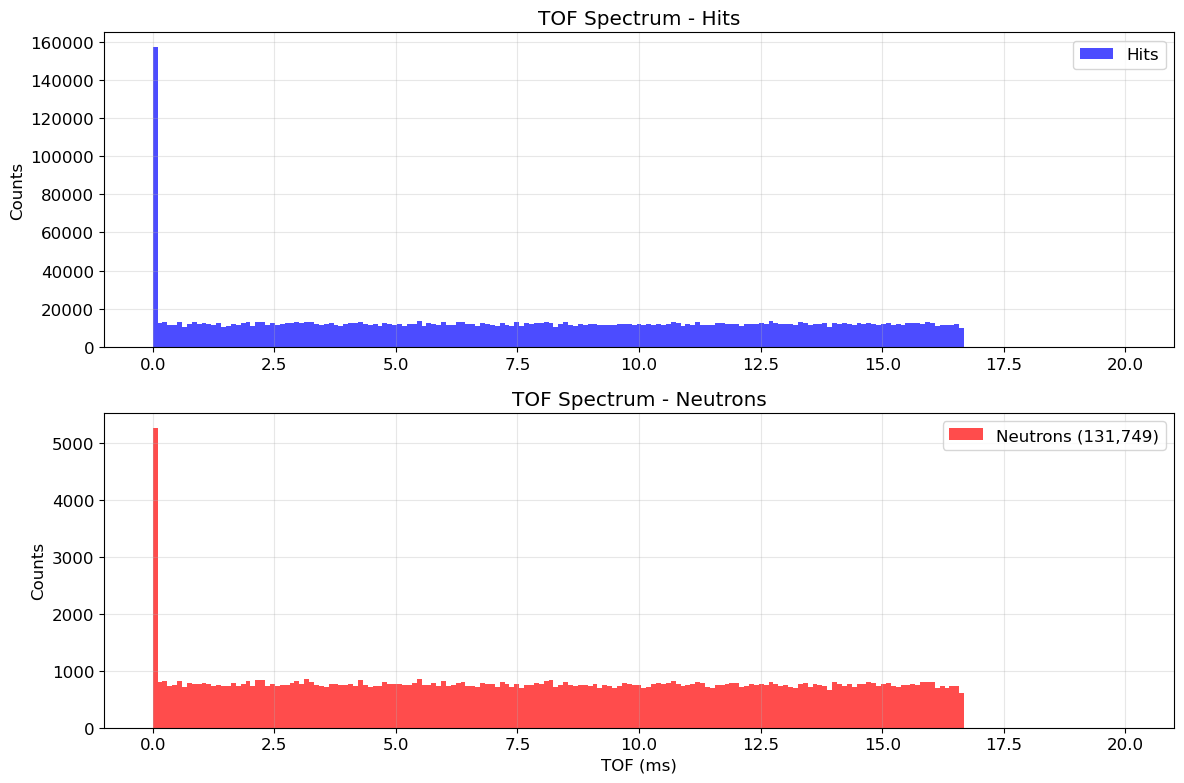

In [16]:
print("=== TOF Analysis ===")

# Convert TOF to milliseconds
hits_tof_ms = hits["tof"] * 25 / 1e6  # 25ns units to ms
neutrons_tof = neutrons["tof"]
neutrons_tof_ms = neutrons_tof * 25 / 1e6

print(f"TOF ranges:")
print(f"  Hits: {hits_tof_ms.min():.3f} - {hits_tof_ms.max():.3f} ms")
print(f"  Neutrons: {neutrons_tof_ms.min():.3f} - {neutrons_tof_ms.max():.3f} ms")

# Create TOF spectra
tof_bins = np.linspace(0, 20, 200)  # 0-20 ms in 200 bins

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Hits TOF spectrum (sample for performance)
# sample_Unique cluster = np.random.choice(len(hits_tof_ms), 1000000, replace=False)
ax1.hist(
    hits_tof_ms,
    bins=tof_bins,
    alpha=0.7,
    label=f"Hits",
    color="blue",
)
ax1.set_ylabel("Counts")
ax1.set_title("TOF Spectrum - Hits")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Neutrons TOF spectrum
ax2.hist(
    neutrons_tof_ms,
    bins=tof_bins,
    alpha=0.7,
    label=f"Neutrons ({len(neutrons_tof_ms):,})",
    color="red",
)
ax2.set_xlabel("TOF (ms)")
ax2.set_ylabel("Counts")
ax2.set_title("TOF Spectrum - Neutrons")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Summary and Verification

In [17]:
print("=== Clustering Verification Summary ===")
print()
print("✅ TPX3 file processing: SUCCESS")
print(f"   - Processed {len(hits):,} hits in {processing_time:.2f} seconds")
print(f"   - Rate: {len(hits) / processing_time / 1e6:.1f} M hits/second")
print()
print("✅ Clustering pipeline: SUCCESS")
print(f"   - Input: {len(hits):,} hits")
print(f"   - Output: {len(neutrons):,} neutrons")
print(f"   - Efficiency: {efficiency:.6f} ({efficiency * 100:.4f}%)")
print(f"   - Processing time: {clustering_time:.2f} seconds")
print()
print("✅ Sub-pixel precision: CONFIRMED")
print(f"   - {non_integer_x:,} neutrons have non-integer X coordinates")
print(f"   - {non_integer_y:,} neutrons have non-integer Y coordinates")
print()
print("✅ Cluster analysis: COMPLETE")
print(f"   - Mean cluster size: {n_hits_field.mean():.1f} hits")
print(f"   - Cluster size range: {n_hits_field.min()} - {n_hits_field.max()} hits")
print(
    f"   - Multi-hit clusters: {multi_hit:,} ({100 * multi_hit / len(neutrons):.1f}%)"
)

=== Clustering Verification Summary ===

✅ TPX3 file processing: SUCCESS
   - Processed 2,168,426 hits in 0.00 seconds
   - Rate: 23320.6 M hits/second

✅ Clustering pipeline: SUCCESS
   - Input: 2,168,426 hits
   - Output: 131,749 neutrons
   - Efficiency: 0.060758 (6.0758%)
   - Processing time: 0.03 seconds

✅ Sub-pixel precision: CONFIRMED
   - 112,979 neutrons have non-integer X coordinates
   - 114,213 neutrons have non-integer Y coordinates

✅ Cluster analysis: COMPLETE
   - Mean cluster size: 16.5 hits
   - Cluster size range: 1 - 4461 hits
   - Multi-hit clusters: 118,845 (90.2%)


In [18]:
    
print(f"Number of hits: {len(x)/1e6} MHits")
print(f"Unique cluster IDs: {np.unique(cluster_id)}")
print(f"Acquisition time: {max(spidertime_ns)*1e-9 - min(spidertime_ns)*1e-9} s")
print(f"Hit rate: {round(len(x)/1e6/(max(spidertime_ns)*1e-9),3)} MHits/s")
# print(f"Time of flight: {np.min(tof_ns)*1e-6} ms to {np.max(tof_ns)*1e-6} ms")

Labelsize=15
DPI=1500

# tof_min_ns=tof_min_ms*1e6
# tof_max_ns=tof_max_ms*1e6

frame_exposure = 1e5 # in ns 
num_frames = 2
acquisition_time = num_frames*frame_exposure
acquisition_time_s=acquisition_time/1000000000

# start_time = spidertime_ns[0+500000*10]
start_time = 10000000
# start_time = 1e10  #50 ms
print(f"Start time: {start_time*1e-9} s")
time_frame = (start_time <= spidertime_ns) & (spidertime_ns <= start_time + acquisition_time)
# Apply the time mask to the hits-level arrays so shapes match
# (some variables like `x`/`y` may refer to `neutrons` earlier; use `hits` here)
slice_x = hits['x'][time_frame]
slice_y = hits['y'][time_frame]
slice_t = spidertime_ns[time_frame]
slice_TOT = tot_ns[time_frame]
slice_cluster = hits['cluster_id'][time_frame]
# unique_labels = np.unique(slice_labels)
x_, y_, t_, cluster_ = slice_x, slice_y, slice_t, slice_cluster

Number of hits: 0.131749 MHits
Unique cluster IDs: [     0      1      2 ... 216169 216170 216171]
Acquisition time: 1.074049647 s
Hit rate: 0.123 MHits/s
Start time: 0.01 s


In [19]:
# detect cluster field and call visualize_clusters
# import numpy as np

print("neutrons fields:", neutrons.dtype.names)
print("hits fields:", hits.dtype.names)

if 'cluster_id' in neutrons.dtype.names:
    xplot = neutrons['x']
    yplot = neutrons['y']
    tplot = neutrons['tof'] if 'tof' in neutrons.dtype.names else (neutrons.get('timestamp', np.zeros(len(neutrons))))
    cluster_arr = neutrons['cluster_id']
    src = 'neutrons'
elif 'cluster_id' in hits.dtype.names:
    # use the sliced hit frame if available, otherwise all hits
    if 'slice_x' in globals() and len(slice_x) > 0:
        xplot = slice_x; yplot = slice_y; tplot = slice_t; cluster_arr = slice_cluster
    else:
        xplot = hits['x']; yplot = hits['y']; tplot = hits.get('timestamp', np.zeros(len(hits))); cluster_arr = hits['cluster_id']
    src = 'hits'
else:
    # fallback: assign one colour per neutron
    xplot = neutrons['x']; yplot = neutrons['y']
    tplot = neutrons['tof'] if 'tof' in neutrons.dtype.names else np.zeros(len(neutrons))
    cluster_arr = np.arange(len(neutrons))
    src = 'assigned index'

print(f"Using cluster IDs from: {src}; unique IDs: {np.unique(cluster_arr).size}")
out2d, out3d = visualize_clusters(xplot, yplot, tplot, cluster_arr,
                                  Pixel2mm=globals().get('Pixel2mm', 1),
                                  save_dir=globals().get('save_Fig_dir', '.'),
                                  prefix=f'cluster_viz_{src}')
print("Wrote:", out2d, out3d)

neutrons fields: ('x', 'y', 'tof', 'tot', 'n_hits', 'chip_id', 'reserved')
hits fields: ('tof', 'x', 'y', 'timestamp', 'tot', 'chip_id', 'cluster_id')
Using cluster IDs from: hits; unique IDs: 26


Wrote: ./cluster_viz_hits_2D.html ./cluster_viz_hits_3D.html


In [20]:
print("clustering algorithm:", getattr(config.clustering, "algorithm", None))
print("min_cluster_size:", config.clustering.abs.min_cluster_size)
print("radius:", config.clustering.abs.radius)
print("neutron_correlation_window (ns):", config.clustering.abs.neutron_correlation_window)

print("Unique neutron n_hits:", np.unique(neutrons["n_hits"], return_counts=True)[:2])
print("Neutrons with n_hits>1:", np.count_nonzero(neutrons["n_hits"]>1))

clustering algorithm: abs
min_cluster_size: 1
radius: 5.0
neutron_correlation_window (ns): 75.0
Unique neutron n_hits: (array([   1,    2,    3,    4,    5,    6,    7,    8,    9,   10,   11,
         12,   13,   14,   15,   16,   17,   18,   19,   20,   21,   22,
         23,   24,   25,   26,   27,   28,   29,   30,   31,   32,   33,
         34,   35,   36,   37,   38,   39,   40,   41,   42,   43,   44,
         45,   46,   47,   48,   49,   50,   51,   52,   53,   54,   55,
         56,   57,   58,   59,   60,   61,   62,   63,   64,   65,   66,
         67,   68,   69,   70,   71,   72,   73,   74,   75,   76,   77,
         78,   79,   80,   81,   82,   83,   84,   85,   86,   87,   88,
         89,   90,   91,   92,   93,   94,   95,   96,   97,   98,   99,
        100,  101,  102,  103,  104,  105,  106,  107,  108,  109,  110,
        111,  112,  113,  114,  115,  116,  117,  118,  119,  120,  121,
        122,  123,  124,  125,  126,  127,  128,  129,  130,  131,  132,
    